In [1]:
import pandas, numpy

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(1/3), 9*(4/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
enrichments_file = '/Users/adrian/research/bmcbf/073_bologna/results/enrichment/clusterProfiler_enrichments.secondVenn.tsv'

In [4]:
df = pandas.read_csv(enrichments_file, sep='\t')
df

,Cluster,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
1,leftList,R-HSA-176974,Unwinding of DNA,4/91,12/11214,0.333333,41.076923,12.563419,1.911294e-06,0.000883,0.000873,8318/9837/51659/84296,4
2,leftList,R-HSA-69190,DNA strand elongation,4/91,32/11214,0.125000,15.403846,7.380136,1.226383e-04,0.028329,0.028013,8318/9837/51659/84296,4
3,leftList,R-HSA-9648895,Response of EIF2AK1 (HRI) to heme deficiency,3/91,15/11214,0.200000,24.646154,8.288714,2.191814e-04,0.031025,0.030678,440/79094/467,3
4,leftList,R-HSA-140877,Formation of Fibrin Clot (Clotting Cascade),4/91,39/11214,0.102564,12.639053,6.585622,2.686131e-04,0.031025,0.030678,3053/7450/2159/7056,4
5,middleList,R-HSA-9925563,Developmental Lineage of Pancreatic Ductal Cells,9/156,48/11214,0.187500,13.478365,10.289977,1.633535e-08,0.000006,0.000005,10319/1277/6662/3855/306/1278/1281/3880/3914,9
6,middleList,R-HSA-1474244,Extracellular matrix organization,20/156,321/11214,0.062305,4.478792,7.510903,1.860123e-08,0.000006,0.000005,3675/2006/10319/59277/7076/1277/6382/4317/6696...,20
7,middleList,R-HSA-2214320,Anchoring fibril formation,6/156,15/11214,0.400000,28.753846,12.775094,2.970598e-08,0.000006,0.000006,1277/1284/1278/1282/1287/3914,6
8,middleList,R-HSA-2173782,Binding and Uptake of Ligands by Scavenger Rec...,8/156,42/11214,0.190476,13.692308,9.787791,9.259620e-08,0.000013,0.000012,1277/1284/1278/1281/6288/1282/3040/3043,8
9,middleList,R-HSA-9734767,Developmental Cell Lineages,12/156,120/11214,0.100000,7.188462,8.094950,9.939513e-08,0.000013,0.000012,5646/10319/1277/6662/3855/306/93099/1278/1281/...,12
10,middleList,R-HSA-3000157,Laminin interactions,7/156,30/11214,0.233333,16.773077,10.274564,1.371084e-07,0.000013,0.000012,3675/10319/1284/3679/1282/1287/3914,7


In [5]:
contrasts = []
for element in df['Cluster']:
    if element not in contrasts:
        contrasts.append(element)

print(contrasts)

['leftList', 'middleList', 'rightList']


In [6]:
terms_to_use = []
top_ten_categories = []
for contrast in contrasts:
    
    print(contrast)
    sub = df[df['Cluster'] == contrast]
    all_observed_gene_lists = []
    contrast_terms = []
    top_ten = []
    
    for index, row in sub.iterrows():
        
        
        genes = row['geneID'].split('/')
        print('\t', row['ID'], row['Description'], len(genes))
        
        # checking the overlap
        overlap = False
        max_overlap = 0
        for element in all_observed_gene_lists:
            intersect = list(set(element) & set(genes))
            relative_intersect = len(intersect)/len(genes)
            #print('\t\t\t intersect is', len(intersect), relative_intersect)
            if max_overlap < relative_intersect:
                max_overlap = relative_intersect
            if relative_intersect > 0.9:
                overlap=True
            
        all_observed_gene_lists.append(genes)

        #print('\t', overlap)
        #print()
        if overlap == False:
            print('\t accepting', row['ID'], row['Description'], 'because overlap is', max_overlap)
            contrast_terms.append(row['ID'])
            if len(contrast_terms) <= 10:
                top_ten.append(row['ID'])
        else:
            print('\t rejecting', row['ID'], row['Description'], 'because overlap is', max_overlap)
        print()

    # end of contrast
    terms_to_use.append(contrast_terms)
    top_ten_categories.append(top_ten)
    print()
    #print(terms_to_use)

leftList
	 R-HSA-176974 Unwinding of DNA 4
	 accepting R-HSA-176974 Unwinding of DNA because overlap is 0

	 R-HSA-69190 DNA strand elongation 4
	 rejecting R-HSA-69190 DNA strand elongation because overlap is 1.0

	 R-HSA-9648895 Response of EIF2AK1 (HRI) to heme deficiency 3
	 accepting R-HSA-9648895 Response of EIF2AK1 (HRI) to heme deficiency because overlap is 0

	 R-HSA-140877 Formation of Fibrin Clot (Clotting Cascade) 4
	 accepting R-HSA-140877 Formation of Fibrin Clot (Clotting Cascade) because overlap is 0


middleList
	 R-HSA-9925563 Developmental Lineage of Pancreatic Ductal Cells 9
	 accepting R-HSA-9925563 Developmental Lineage of Pancreatic Ductal Cells because overlap is 0

	 R-HSA-1474244 Extracellular matrix organization 20
	 accepting R-HSA-1474244 Extracellular matrix organization because overlap is 0.25

	 R-HSA-2214320 Anchoring fibril formation 6
	 rejecting R-HSA-2214320 Anchoring fibril formation because overlap is 1.0

	 R-HSA-2173782 Binding and Uptake of Lig

In [7]:
for content in terms_to_use:
    print(len(content), content)

print()

for top_ten in top_ten_categories:
    print(len(top_ten), top_ten)

union_list = list(set(item for sublist in top_ten_categories for item in sublist))

print()

print(len(union_list), union_list)

3 ['R-HSA-176974', 'R-HSA-9648895', 'R-HSA-140877']
6 ['R-HSA-9925563', 'R-HSA-1474244', 'R-HSA-2173782', 'R-HSA-9734767', 'R-HSA-6809371', 'R-HSA-9648895']
1 ['R-HSA-156711']

3 ['R-HSA-176974', 'R-HSA-9648895', 'R-HSA-140877']
6 ['R-HSA-9925563', 'R-HSA-1474244', 'R-HSA-2173782', 'R-HSA-9734767', 'R-HSA-6809371', 'R-HSA-9648895']
1 ['R-HSA-156711']

9 ['R-HSA-1474244', 'R-HSA-156711', 'R-HSA-140877', 'R-HSA-9925563', 'R-HSA-176974', 'R-HSA-6809371', 'R-HSA-2173782', 'R-HSA-9734767', 'R-HSA-9648895']


[['R-HSA-176974', 'R-HSA-9648895', 'R-HSA-140877'], ['R-HSA-9925563', 'R-HSA-1474244', 'R-HSA-2173782', 'R-HSA-9734767', 'R-HSA-6809371', 'R-HSA-9648895'], ['R-HSA-156711']]
-1 R-HSA-176974
-2 R-HSA-9648895
-3 R-HSA-140877
-4 R-HSA-9925563
-5 R-HSA-1474244
-6 R-HSA-2173782
-7 R-HSA-9734767
-8 R-HSA-6809371
-2 R-HSA-9648895
-9 R-HSA-156711


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_2186/2323570530.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  matplotlib.pyplot.tight_layout()


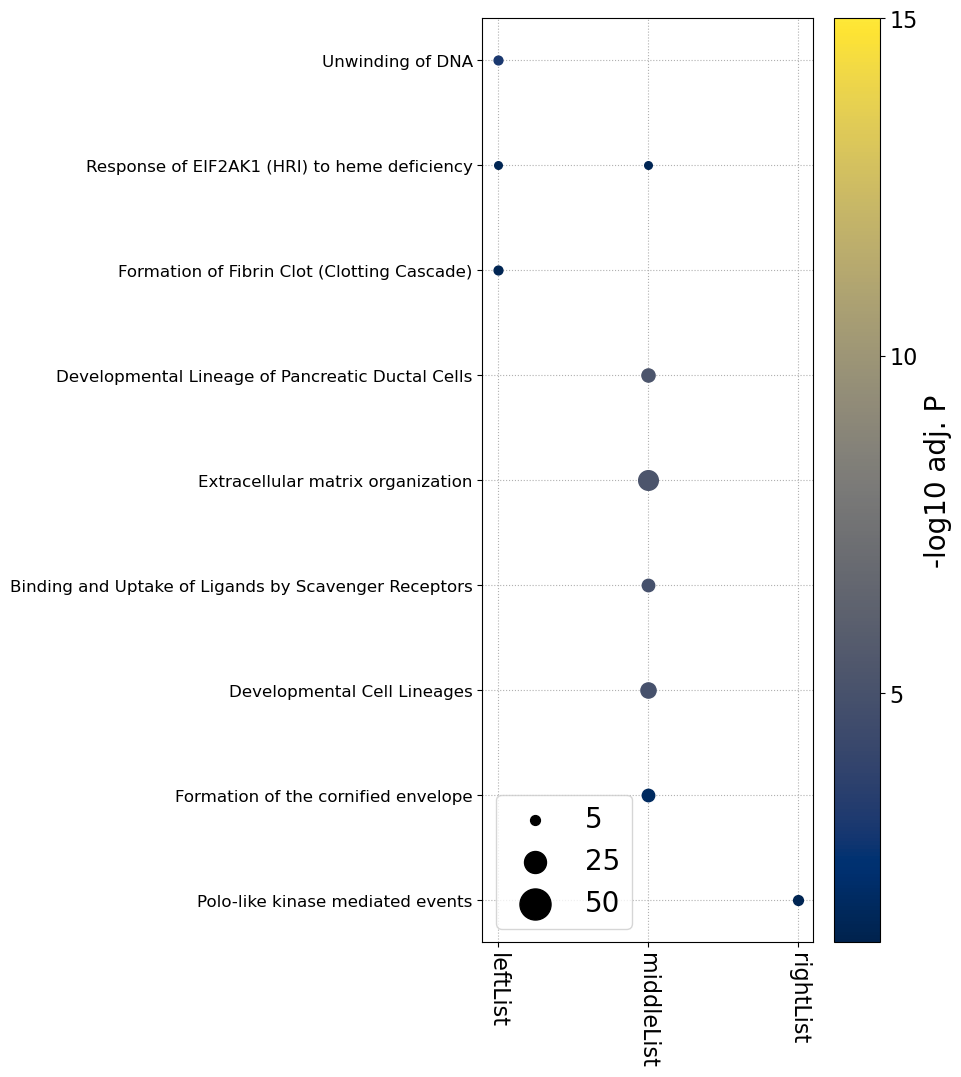

In [8]:
terms_used_so_far = {}
depth = 0
print(terms_to_use)
factor_size_circles = 10
for i in range(len(terms_to_use)):
    for j in range(len(terms_to_use[i])):
        element = terms_to_use[i][j]

        if element in union_list:
        
            if element in terms_used_so_far.keys():
                location = terms_used_so_far[element]
            else:
                depth = depth - 1
                location = depth
    
            # define color
            adjp = -numpy.log10(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['p.adjust'].values[0])
            #print(element, adjp)
    
            # define size
            thesize = int(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['GeneRatio'].values[0].split('/')[0])
            
            # make a point        
            matplotlib.pyplot.scatter(i, location, s=thesize*factor_size_circles, c=adjp, zorder=9999, cmap='cividis', vmin=-numpy.log10(0.05), vmax=15)
            terms_used_so_far[element] = location
            print(location, element)


matplotlib.pyplot.colorbar(label='-log10 adj. P', ticks=[5, 10, 15])

# close the figure
a = []; b = []
for element in terms_used_so_far.keys():
    description = list(df[df['ID'] == element]['Description'].values)[0]
    a.append(description)
    b.append(terms_used_so_far[element])

for area in factor_size_circles*numpy.array([5, 25, 50]):
    matplotlib.pyplot.scatter([], [], c='black', edgecolor=None, s=area, label=str(int(area/factor_size_circles)))
matplotlib.pyplot.legend(loc=3)

matplotlib.pyplot.yticks(b, a, fontsize=12)
matplotlib.pyplot.xticks(list(range(len(contrasts))), 
                         contrasts, 
                         rotation=-90)

#matplotlib.pyplot.ylim(-40.75, -0.25)
matplotlib.pyplot.grid(ls=':')
matplotlib.pyplot.tight_layout()

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('enrichment_second.svg')

In [9]:
list(range(len(contrasts)))

[0, 1, 2]

In [10]:
len(contrasts)

3